# GRIDWORLD A

In [42]:
import numpy as np
import random
import matplotlib.pyplot as plt


class GridWorld:
    def __init__(self, width, height, start, goal, obstacles):
        self.width = width
        self.height = height
        self.start = start
        self.goal = goal
        self.obstacles = obstacles
        self.state = start

    def reset(self):
        self.state = self.start
        return self.state

    def step(self, action):
        x, y = self.state
        if action == 0:
            x = max(x - 1, 0)
        elif action == 1:
            x = min(x + 1, self.height - 1)
        elif action == 2:
            y = max(y - 1, 0)
        elif action == 3:
            y = min(y + 1, self.width - 1)

        next_state = (x, y)

        if next_state in self.obstacles:
            reward = -10
            done = True
        elif next_state == self.goal:
            reward = 10
            done = True
        else:
            reward = -1
            done = False

        self.state = next_state
        return next_state, reward, done

## Algorithms

In [43]:
def epsilon_greedy_policy(Q, state, epsilon):
    if random.uniform(0, 1) < epsilon:
        return random.randint(0, 3)  # Explore: choose a random action
    else:
        q_values = Q[state[0], state[1]]
        max_q = np.max(q_values)
        best_actions = np.where(q_values == max_q)[0]
        return random.choice(best_actions)  # Exploit: choose the best action

In [44]:
def sarsa(env, episodes, alpha, gamma, epsilon, max_steps=500):
    Q = np.zeros((env.height, env.width, 4))
    steps_per_episode = []
    rewards_per_episode = []

    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy_policy(Q, state, epsilon)
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            next_state, reward, done = env.step(action)
            next_action = epsilon_greedy_policy(Q, next_state, epsilon)
            Q[state[0], state[1], action] += alpha * (reward + gamma * Q[next_state[0], next_state[1], next_action] - Q[state[0], state[1], action])
            state = next_state
            action = next_action
            total_reward += reward
            steps += 1

        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)

    return Q, steps_per_episode, rewards_per_episode


In [45]:
def evaluate(env, Q, trials=100, max_steps=500):
    steps_list = []
    for _ in range(trials):
        state = env.reset()
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = epsilon_greedy_policy(Q, state, epsilon=0)
            state, _, done = env.step(action)
            steps += 1
        steps_list.append(steps)
    return np.mean(steps_list), np.std(steps_list)


In [46]:
def q_learning(env, episodes, alpha, gamma, epsilon, max_steps=500):
    Q = np.zeros((env.height, env.width, 4))
    steps_per_episode = []
    rewards_per_episode = []

    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy_policy(Q, state, epsilon)
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            next_state, reward, done = env.step(action)
            Q[state[0], state[1], action] += alpha * (reward + gamma * np.max(Q[next_state[0], next_state[1]]) - Q[state[0], state[1], action])
            state = next_state
            action = epsilon_greedy_policy(Q, state, epsilon)
            total_reward += reward
            steps += 1

        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)

    return Q, steps_per_episode, rewards_per_episode


In [47]:
def double_q_learning(env, episodes, alpha, gamma, epsilon, max_steps=500):
    Q1 = np.zeros((env.height, env.width, 4))
    Q2 = np.zeros((env.height, env.width, 4))
    steps_per_episode = []
    rewards_per_episode = []

    for episode in range(episodes):
        state = env.reset()
        action = epsilon_greedy_policy(Q1 + Q2, state, epsilon)
        done = False
        total_reward = 0
        steps = 0

        while not done and steps < max_steps:
            next_state, reward, done = env.step(action)

            if random.random() < 0.5:
                best_action = np.argmax(Q1[next_state[0], next_state[1]])
                Q1[state[0], state[1], action] += alpha * (reward + gamma * Q2[next_state[0], next_state[1], best_action] - Q1[state[0], state[1], action])
            else:
                best_action = np.argmax(Q2[next_state[0], next_state[1]])
                Q2[state[0], state[1], action] += alpha * (reward + gamma * Q1[next_state[0], next_state[1], best_action] - Q2[state[0], state[1], action])

            state = next_state
            action = epsilon_greedy_policy(Q1 + Q2, state, epsilon)
            total_reward += reward
            steps += 1

        steps_per_episode.append(steps)
        rewards_per_episode.append(total_reward)

    Q = (Q1 + Q2) / 2
    return Q, steps_per_episode, rewards_per_episode


In [48]:
def smooth(data, window=50):
    kernel = np.ones(window) / window
    return np.convolve(data, kernel, mode='valid')

def convergence_time(steps_per_episode, buffer=30, window=50):
    optimal = min(steps_per_episode)
    threshold = optimal + buffer
    smoothed = smooth(steps_per_episode, window)
    for i, val in enumerate(smoothed):
        if val <= threshold:
            return i + window
    return len(steps_per_episode)  # never converged

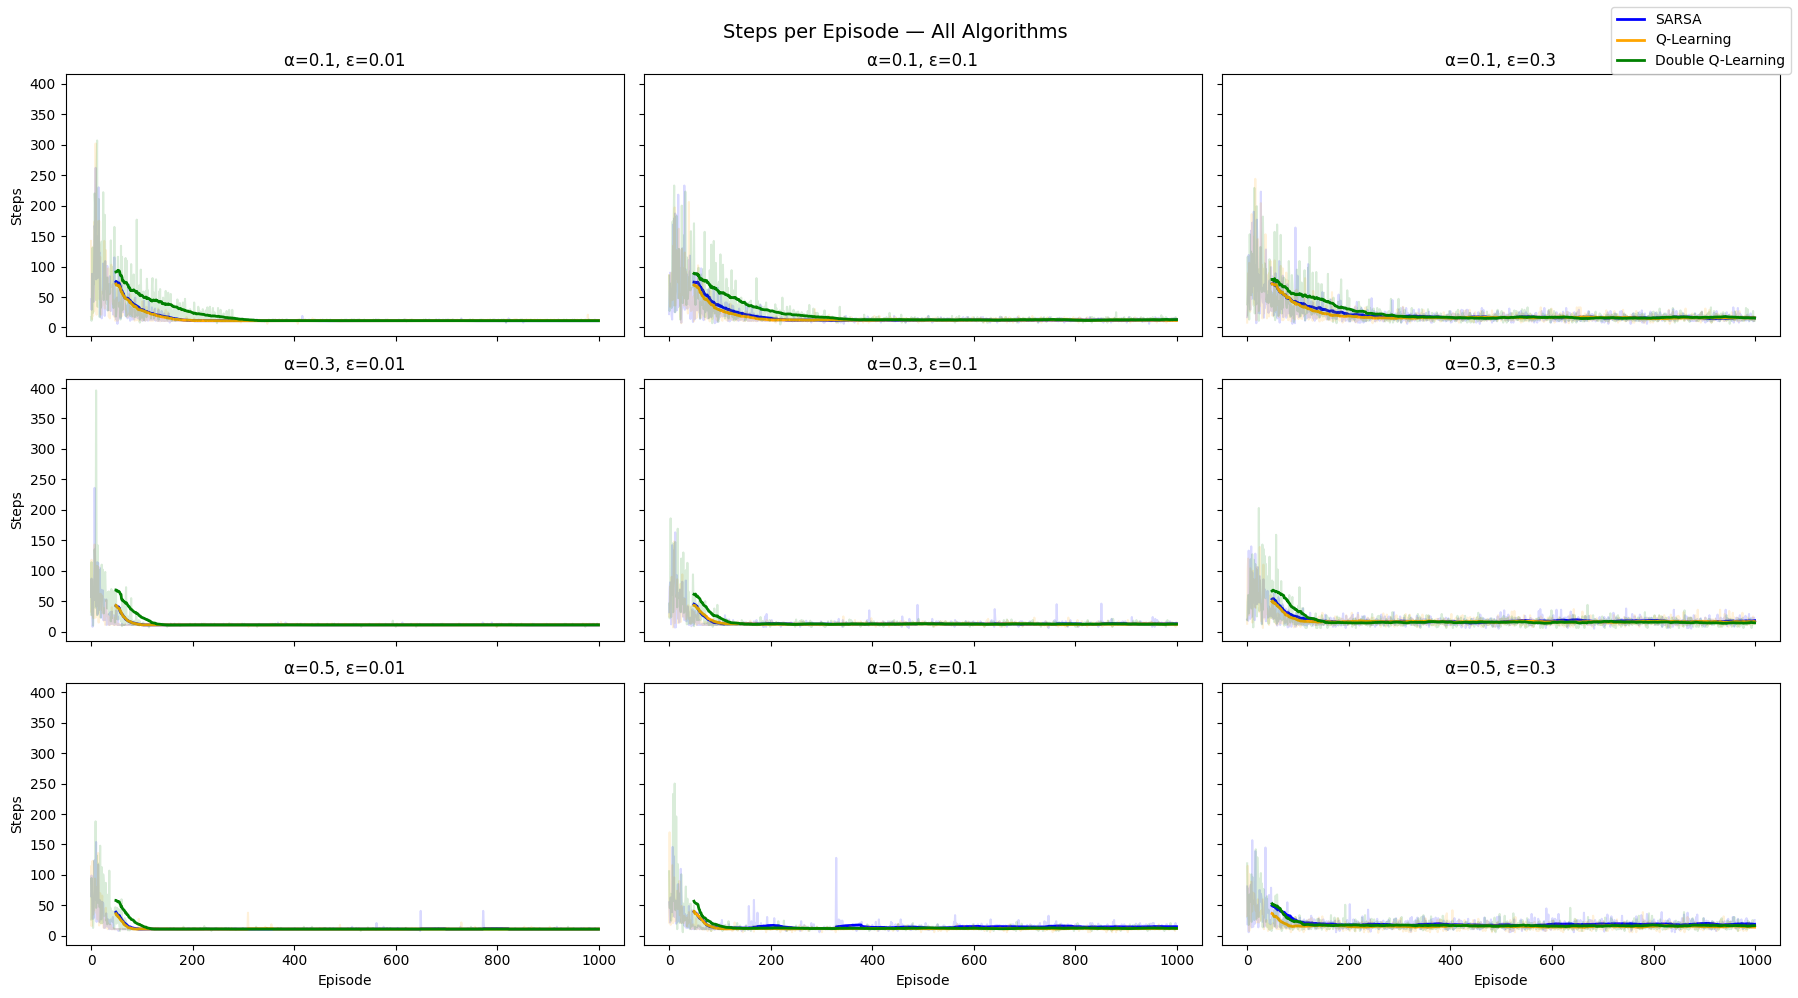

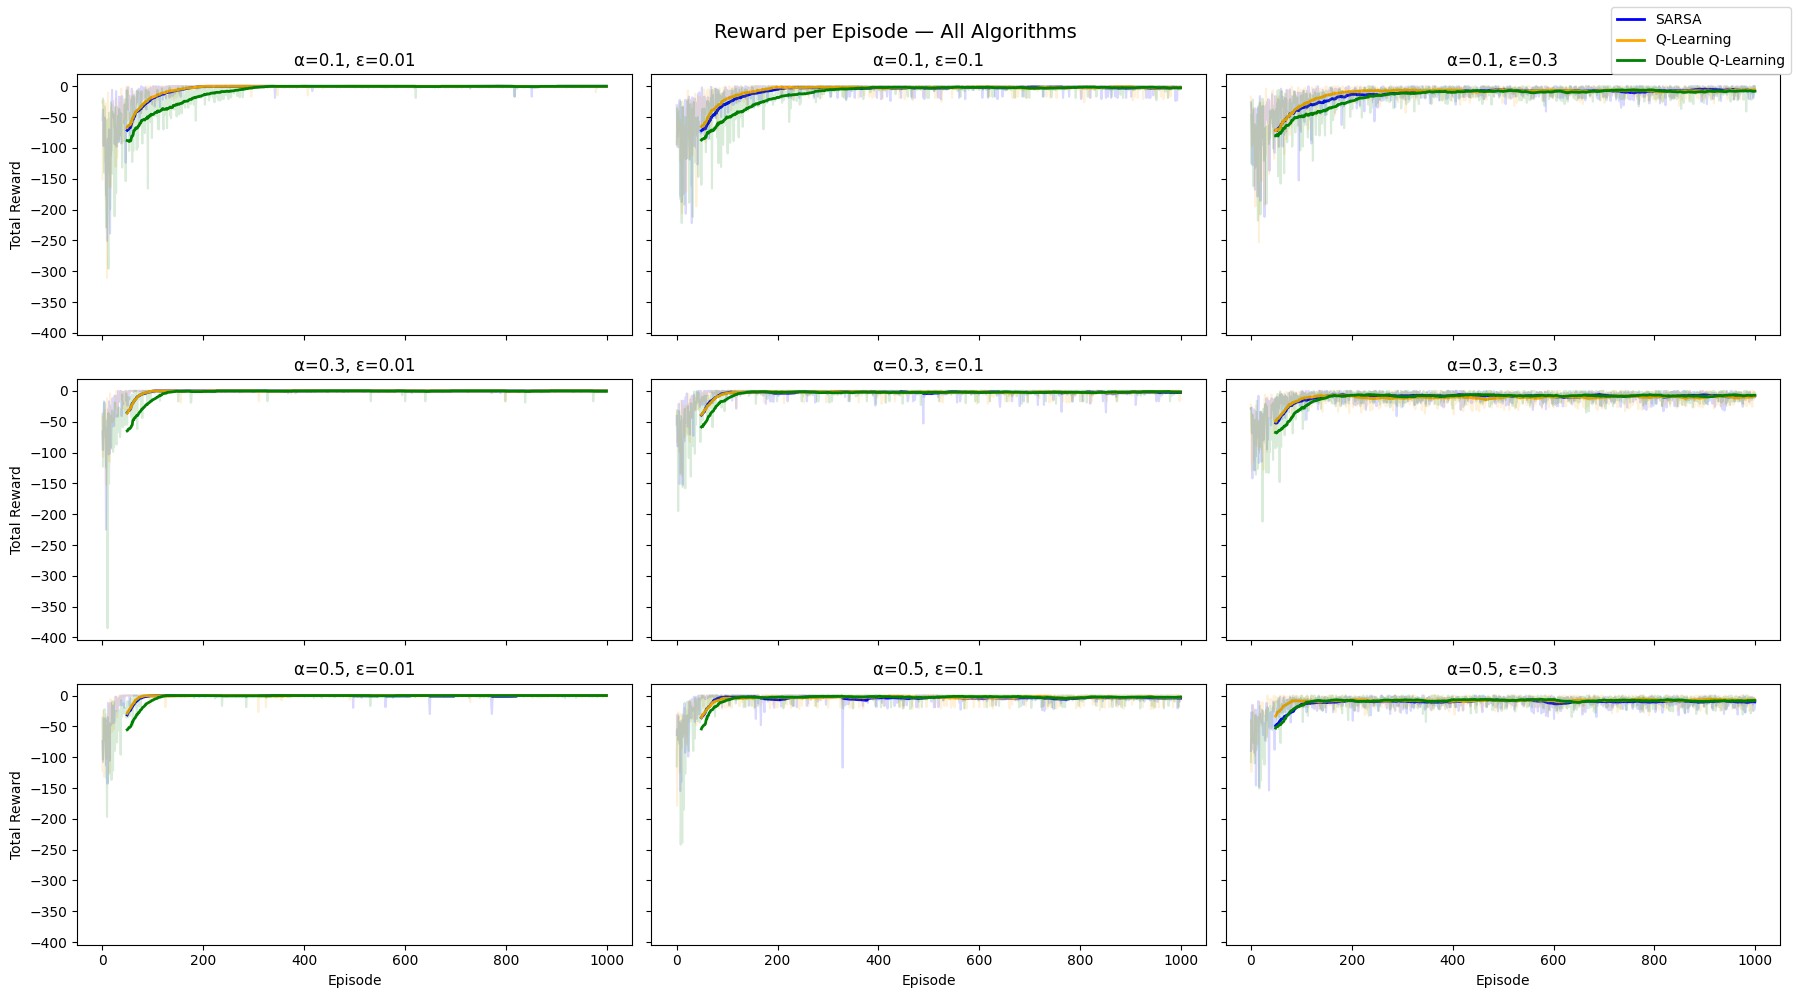

CONVERGENCE TIME (episode where rolling avg steps first drops to near-optimal)
Algorithm            α      ε       Conv. Episode
--------------------------------------------------
SARSA                0.1    0.01               91
SARSA                0.1    0.1               100
SARSA                0.1    0.3               117
SARSA                0.3    0.01               58
SARSA                0.3    0.1                60
SARSA                0.3    0.3                74
SARSA                0.5    0.01               51
SARSA                0.5    0.1                56
SARSA                0.5    0.3                77

Q-Learning           0.1    0.01               85
Q-Learning           0.1    0.1                90
Q-Learning           0.1    0.3               105
Q-Learning           0.3    0.01               56
Q-Learning           0.3    0.1                60
Q-Learning           0.3    0.3                69
Q-Learning           0.5    0.01               50
Q-Learning         

In [49]:
if __name__ == "__main__":

    width = 10
    height = 7
    start = (3, 0)
    goal = (3, 7)
    obstacles = [(1, 5), (2, 5), (3, 5), (4, 5)]
    env = GridWorld(width, height, start, goal, obstacles)

    episodes = 1000
    gamma = 0.99

    epsilons = [0.01, 0.1, 0.3]
    alphas = [0.1, 0.3, 0.5]

    algorithms = {
        "SARSA": sarsa,
        "Q-Learning": q_learning,
        "Double Q-Learning": double_q_learning,
    }
    colors = {"SARSA": "blue", "Q-Learning": "orange", "Double Q-Learning": "green"}

    # --- Train all combinations ---
    results = {}
    for algo_name, algo_fn in algorithms.items():
        for alpha in alphas:
            for eps in epsilons:
                Q, steps, rewards = algo_fn(env, episodes, alpha=alpha, gamma=gamma, epsilon=eps)
                results[(algo_name, alpha, eps)] = (Q, steps, rewards)

    # --- Learning curves: Steps per episode (raw + smoothed) ---
    fig, axes = plt.subplots(len(alphas), len(epsilons), figsize=(18, 10), sharex=True, sharey=True)
    fig.suptitle("Steps per Episode — All Algorithms", fontsize=14)
    for i, alpha in enumerate(alphas):
        for j, eps in enumerate(epsilons):
            ax = axes[i][j]
            for algo_name in algorithms:
                _, steps, _ = results[(algo_name, alpha, eps)]
                ax.plot(steps, color=colors[algo_name], alpha=0.15)
                ax.plot(range(49, len(steps)), smooth(steps), color=colors[algo_name], linewidth=2, label=algo_name)
            ax.set_title(f"α={alpha}, ε={eps}")
            if i == len(alphas) - 1:
                ax.set_xlabel("Episode")
            if j == 0:
                ax.set_ylabel("Steps")
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Learning curves: Reward per episode (raw + smoothed) ---
    fig, axes = plt.subplots(len(alphas), len(epsilons), figsize=(18, 10), sharex=True, sharey=True)
    fig.suptitle("Reward per Episode — All Algorithms", fontsize=14)
    for i, alpha in enumerate(alphas):
        for j, eps in enumerate(epsilons):
            ax = axes[i][j]
            for algo_name in algorithms:
                _, _, rewards = results[(algo_name, alpha, eps)]
                ax.plot(rewards, color=colors[algo_name], alpha=0.15)
                ax.plot(range(49, len(rewards)), smooth(rewards), color=colors[algo_name], linewidth=2, label=algo_name)
            ax.set_title(f"α={alpha}, ε={eps}")
            if i == len(alphas) - 1:
                ax.set_xlabel("Episode")
            if j == 0:
                ax.set_ylabel("Total Reward")
    handles, labels = axes[0][0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    plt.tight_layout()
    plt.show()

    # --- Convergence Time ---
    print("CONVERGENCE TIME (episode where rolling avg steps first drops to near-optimal)")
    print(f"{'Algorithm':<20} {'α':<6} {'ε':<6} {'Conv. Episode':>14}")
    print("-" * 50)
    for algo_name in algorithms:
        for alpha in alphas:
            for eps in epsilons:
                _, steps, _ = results[(algo_name, alpha, eps)]
                conv = convergence_time(steps)
                print(f"{algo_name:<20} {alpha:<6} {eps:<6} {conv:>14}")
        print()

    # --- Path Efficiency ---
    print("\nPATH EFFICIENCY (avg steps over 100 greedy trials after training)")
    print(f"{'Algorithm':<20} {'α':<6} {'ε':<6} {'Avg Steps':>10}")
    print("-" * 46)
    for algo_name in algorithms:
        for alpha in alphas:
            for eps in epsilons:
                Q, _, _ = results[(algo_name, alpha, eps)]
                mean, _ = evaluate(env, Q)
                print(f"{algo_name:<20} {alpha:<6} {eps:<6} {mean:>10.2f}")
        print()

    # --- Robustness (multiple seeds) ---
    n_seeds = 10
    print("\nROBUSTNESS (std dev of avg steps across 10 training seeds)")
    print(f"{'Algorithm':<20} {'α':<6} {'ε':<6} {'Avg Steps':>10} {'Std Dev':>10}")
    print("-" * 58)
    for algo_name, algo_fn in algorithms.items():
        for alpha in alphas:
            for eps in epsilons:
                seed_means = []
                for seed in range(n_seeds):
                    random.seed(seed)
                    np.random.seed(seed)
                    Q, _, _ = algo_fn(env, episodes, alpha=alpha, gamma=gamma, epsilon=eps)
                    mean, _ = evaluate(env, Q)
                    seed_means.append(mean)
                print(f"{algo_name:<20} {alpha:<6} {eps:<6} {np.mean(seed_means):>10.2f} {np.std(seed_means):>10.2f}")
        print()